# Lesson 111 · OGB benchmark contract

<p class="stream-kicker">OGB setup · identify the experiment before reading its score</p>

**Your win:** load an official graph benchmark, verify its split identities, run a training-only constant baseline, and explain what the evaluator's number means.

[Lesson 110](https://avistian.github.io/relational/lessons/0110-temporal-gnn-checkpoint.html) showed that a saved predictor needs a complete state and information contract. A benchmark adds another contract: everyone must answer the same questions under the same scoring rule. This prepares the GCN reproduction in [Lesson 112](https://avistian.github.io/relational/lessons/0112-ogb-gcn-reproduction.html) and the RelBench experiments in Year 4.

**Route:** read and trace the example in about 20 minutes, then implement two notebook functions. Loading the full graph needs a separate data download and several hundred MB of memory; no GPU or paid training is required.

[Student notebook](https://avistian.github.io/relational/labs/0111-ogb-benchmark-contract.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/0111-ogb-benchmark-contract.html) · [Reference card](https://avistian.github.io/relational/reference/ogb-benchmark-contract.html) · [Exact commands](https://avistian.github.io/relational/labs/l111-reproduction.md)







**Read first:** the [official OGB node-prediction specification](https://ogb.stanford.edu/docs/nodeprop/#ogbn-arxiv), then [Hu et al., OGB, §3 and §4.3](https://arxiv.org/html/2005.00687v6). Focus on the task definition, official split and evaluator. The current leaderboard and the historical paper table are separate snapshots of evidence.

## 2 · Five objects, five jobs

A **benchmark** fixes prediction problems and evaluation rules. A **dataset** supplies the graph and feature rows. A **split** assigns node IDs to training, validation or test. A **predictor** maps inputs to answers. An **evaluator** compares those answers with the corresponding labels.

Our selected task is `ogbn-arxiv`: predict a paper's subject category. The released features have 128 coordinates and the target has 40 classes. The official split uses publication year: through 2017 for training, 2018 for validation, and 2019 onward for test. These are official IDs, not a new random split. [Dataset specification](https://ogb.stanford.edu/docs/nodeprop/#ogbn-arxiv).

The library-agnostic loader makes the interface visible:

```python
from ogb.nodeproppred import NodePropPredDataset, Evaluator

dataset = NodePropPredDataset(name="ogbn-arxiv", root="ogb-data")
graph, labels = dataset[0]
splits = dataset.get_idx_split()
evaluator = Evaluator(name="ogbn-arxiv")
```

`graph['node_feat'][i]` and `labels[i]` describe the same node i. An edge uses node indices too. A split index is not an independent row counter. Reordering features without remapping edges and labels changes the question.

**TODO 1 — audit the partition.** Require integer, in-range, nonduplicated IDs. Check that the three splits have no overlap and together cover this dataset's nodes. The notebook supplies deliberate overlap, duplicate and out-of-range cases. Merely checking split sizes would miss a swapped or repeated ID. Full membership hashes are recorded in the author report.

## 3 · Information access is not the same as label access

<figure class="stream-figure" tabindex="0">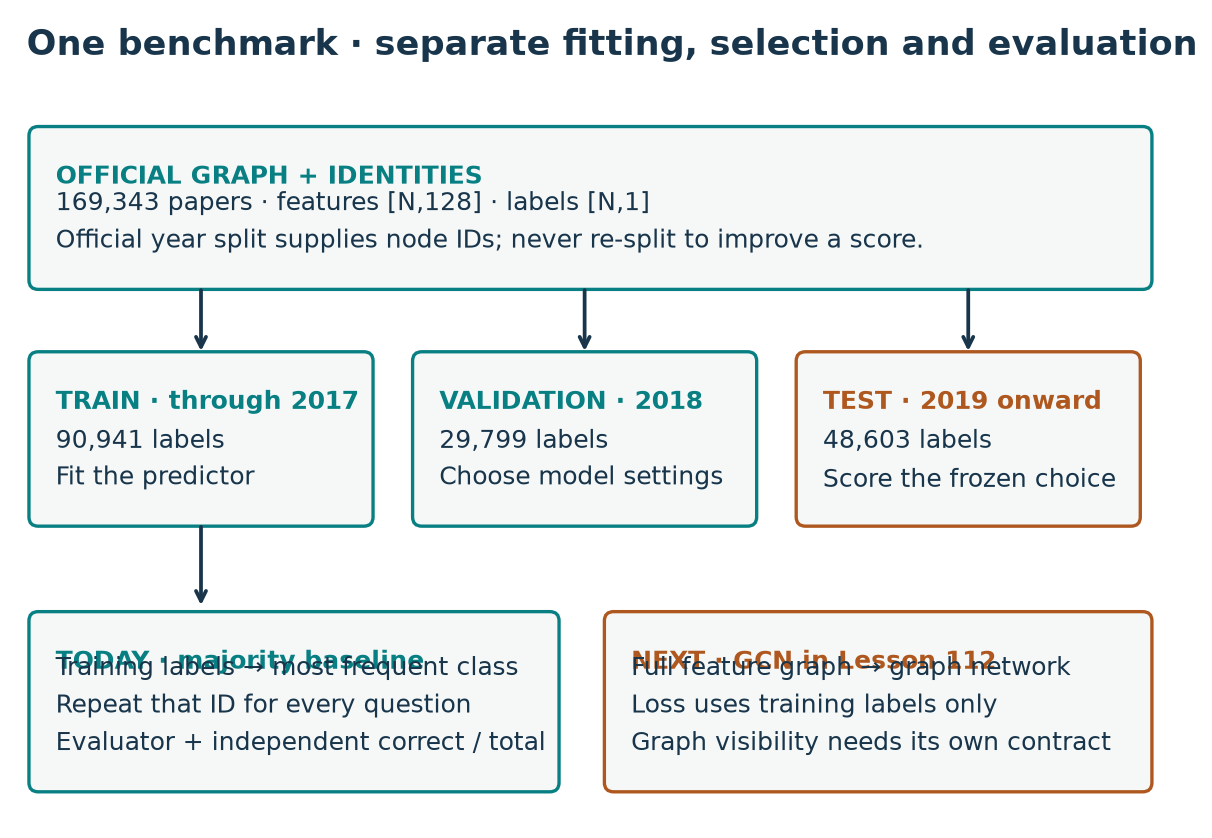<figcaption>One graph, three label roles. Label splitting and feature visibility are separate contracts.</figcaption></figure>

**Read the diagram:** follow the three label branches separately. Training labels fit the predictor; validation labels guide choices; test labels judge the frozen result. The feature graph has its own visibility policy.

The published GCN baseline is transductive: it propagates on the released feature graph, then restricts its training objective to training labels. **Transductive** means that held-out feature rows and structure can participate without using their labels for fitting. A year-based label split therefore does not by itself certify a historically available feature graph. The exact GCN implementation is studied next; see the [pinned released training code](https://github.com/snap-stanford/ogb/blob/61e9784ca76edeaa6e259ba0f836099608ff0586/examples/nodeproppred/arxiv/gnn.py).

Our simple baseline ignores features and edges entirely. It predicts the most frequent **training** class for every node. This is a useful plumbing check: it checks split counts, training-only fitting and basic scoring before neural training. A constant predictor cannot detect every alignment error. It is not a competitive graph model.

**Worked example.** Training labels `[2,1,2,0]` choose class 2. For held-out labels `[2,0,2,1]`, predictions `[2,2,2,2]` get two of four correct: accuracy 0.5. Changing those held-out labels may change the measured score, but must not change the chosen class.

**TODO 2 — fit without held-out labels.** Implement `majority_predictions`. Count only `labels[train_idx]`. Return shape `[N,1]`; break a frequency tie by the smallest class ID. A test changes every held-out label and demands unchanged predictions.

## 4 · Score aligned answers using the official evaluator

```python
idx = splits['valid']
score = evaluator.eval({
    "y_true": labels[idx],
    "y_pred": predictions[idx],
})["acc"]
```

For this task, the evaluator expects class IDs in `[number of evaluated nodes, 1]`, not a matrix of probabilities. A neural network's class logits would first use `argmax(axis=1, keepdims=True)`. Both labels and predictions must use the same split indices and ordering.

**Accuracy** is correct predictions divided by evaluated nodes. Independently compute that fraction and compare it to the official result. Agreement checks the arithmetic; the split audit checks which questions were scored.

**A constant baseline can hide a row-order bug.** Suppose the evaluated node IDs are `[41, 7]` and their true labels are `[2, 0]`. A constant class-2 predictor has accuracy 1/2 whether its two rows are swapped or not. Passing that check does not prove that node identities are aligned.

<table class="compact-trace" style="min-width:0;border-collapse:separate;border-spacing:.4em .25em"><thead><tr><th>Predictions in node order [41, 7]</th><th>Accuracy</th></tr></thead><tbody><tr><td>Constant: [2, 2]</td><td>1/2</td></tr><tr><td>Aligned model: [2, 0]</td><td>2/2</td></tr><tr><td>Swapped model: [0, 2]</td><td>0/2</td></tr></tbody></table>

If a prediction file stores `(node_id, prediction)` as `(7, 0), (41, 2)`, first look up both predictions in the split’s order `[41, 7]`. Passing the file’s raw order `[0, 2]` to the evaluator produces a valid-looking number for the wrong pairs. The evaluator receives label and prediction arrays; it does not see the node IDs needed to repair the pairing.

**Try it:** reorder both labels and predictions together. Does accuracy change? Then reorder only predictions. Explain why shape validation cannot distinguish these cases.

<details><summary>Check the identity argument</summary><p>Reordering both arrays together preserves every pair and the score. Reordering only predictions can change which node gets each answer; here accuracy falls from 1 to 0. Both arrays still have shape [2,1]. Use an explicit ID lookup or join, and reject missing or duplicated prediction IDs before scoring. Keep the majority baseline as a useful check, alongside this nonconstant alignment witness.</p></details>

| Split | Official nodes | Majority accuracy |
|---|---:|---:|
| train | 90,941 | 17.9061% |
| valid | 29,799 | 7.6278% |
| test | 48,603 | 5.8618% |

Chosen training class: **28**. [Full identity and score report](https://avistian.github.io/relational/labs/evidence/l111/summary.json).

> **Evidence boundary.** These are fresh full-data scores for a course majority baseline. There is no optimization, random seed study or validation tuning. The published GCN experiment is not reproduced in this lesson. Lesson 112 provides that separate named reproduction. Running this package does not establish learner mastery.

The notebook authenticates the raw archive and uses the official loader on a fresh temporary extraction. This avoids depending on an old processed pickle cache whose loading behavior varies with PyTorch versions. The original archive is reusable; the notebook does not alter another lesson's processed cache.

## 5 · Read a leaderboard as a protocol, not a ranking alone

Before comparing two rows, record: dataset and release, split IDs, feature and edge transformations, model, training schedule, validation selection, metric, run count and uncertainty. A higher test score is not a reproduction failure repair if the change was chosen after looking at test results.

**Worked selection.** Validation accuracies `[0.60,0.70,0.70]` select the second epoch under a first-maximum rule. Test scores `[0.80,0.65,0.90]` do not change that choice. Reporting 0.90 would select a different predictor using test labels.

<details><summary>Transfer check: what must be frozen for a fair comparison?</summary><p>Keep the dataset identities, evaluated questions, information policy and scoring rule fixed. Record any architecture, preprocessing, compute or selection differences. Equal epoch counts alone do not establish equal tuning effort.</p></details>

## EXIT · deliver a benchmark contract

Submit both functions, the full-data report and a short explanation of four points: what each split does; why held-out labels cannot fit your baseline; why the GCN's graph visibility differs from your constant predictor; and what evidence a historical reproduction claim would still require.

Tomorrow, reconstruct the five objects without notes. In a week, apply the same checklist to a relational task. Ask the teaching agent about any unclear index, score or evidence boundary. Learner status remains **PENDING_WRITTEN_DEFENSE**.

**Carry this forward:** [Lesson 112](https://avistian.github.io/relational/lessons/0112-ogb-gcn-reproduction.html) keeps these official questions and replaces the constant with a complete GCN, validation-selected state and ten fresh fits.


In [1]:
# @colab-bootstrap
import sys, subprocess
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable,'-m','pip','install','ogb==1.3.6'])

## Implement, then check

The two TODO functions below are used by the full-data run. First predict the effect of overlapping split IDs and changed held-out labels.

In [2]:
"""Visible OGB setup and train-only constant baseline; no GCN training."""
import hashlib
import json
import os
import tempfile
import urllib.request
import zipfile
from pathlib import Path
import numpy as np
from ogb.nodeproppred import NodePropPredDataset, Evaluator


def audit_splits(splits, num_nodes):
    """Require a complete, nonoverlapping partition of integer node identities."""
    if set(splits) != {'train', 'valid', 'test'}:
        raise ValueError('Expected the three official split names')
    parts = []
    counts = {}
    for name, indices in splits.items():
        indices = np.asarray(indices)
        if indices.ndim != 1 or indices.dtype.kind not in 'iu':
            raise ValueError('Split IDs must be a one-dimensional integer array')
        if len(indices) == 0 or np.any(indices < 0) or np.any(indices >= num_nodes):
            raise ValueError('Empty split or node ID outside the graph')
        counts[name] = len(indices)
        parts.append(indices)
    combined = np.concatenate(parts)
    if len(combined) != num_nodes or len(np.unique(combined)) != num_nodes:
        raise ValueError('Missing, repeated or overlapping node IDs')
    return counts


def majority_predictions(labels, train_idx):
    """Fit a constant from training labels only; smallest class wins a tie."""
    labels = np.asarray(labels)
    if labels.ndim != 2 or labels.shape[1] != 1:
        raise ValueError('Expected [N,1] labels')
    values, counts = np.unique(labels[train_idx, 0], return_counts=True)
    if not len(values):
        raise ValueError('Training labels are empty')
    chosen = values[np.argmax(counts)]
    return np.full(labels.shape, chosen, dtype=labels.dtype)


def load_official(archive):
    """Authenticate raw bytes; avoid old pickle caches with newer PyTorch."""
    archive = Path(archive)
    if not archive.exists():
        archive.parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve('https://snap.stanford.edu/ogb/data/nodeproppred/arxiv.zip', archive)
    expected = '49f85c801589ecdcc52cfaca99693aaea7b8af16a9ac3f41dd85a5f3193fe276'
    if hashlib.sha256(archive.read_bytes()).hexdigest() != expected:
        raise ValueError('Archive differs from the frozen OGB input')
    with tempfile.TemporaryDirectory(prefix='l111-official-') as tmp:
        with zipfile.ZipFile(archive) as z:
            z.extractall(tmp)
        folder = Path(tmp)/'ogbn_arxiv'
        (Path(tmp)/'arxiv').rename(folder)
        (folder/'RELEASE_v1.txt').touch()
        dataset = NodePropPredDataset(name='ogbn-arxiv', root=tmp)
        return dataset[0], dataset.get_idx_split()


def run_contract(archive):
    (graph, labels), splits = load_official(archive)
    counts = audit_splits(splits, graph['num_nodes'])
    predictions = majority_predictions(labels, splits['train'])
    evaluator = Evaluator(name='ogbn-arxiv')
    scores = {}
    for name, idx in splits.items():
        official = evaluator.eval({'y_true': labels[idx], 'y_pred': predictions[idx]})['acc']
        independent = float(np.mean(labels[idx] == predictions[idx]))
        assert official == independent
        scores[name] = official
    years = graph['node_year'].reshape(-1)
    assert years[splits['train']].max() <= 2017
    assert np.all(years[splits['valid']] == 2018)
    assert years[splits['test']].min() >= 2019
    return dict(status='PASS', dataset='ogbn-arxiv', nodes=graph['num_nodes'],
                feature_shape=list(graph['node_feat'].shape), split_counts=counts,
                split_sha256={k:hashlib.sha256(np.asarray(v,dtype='<i8').tobytes()).hexdigest() for k,v in splits.items()},
                label_sha256=hashlib.sha256(np.asarray(labels,dtype='<i8').tobytes()).hexdigest(),
                baseline='Training-majority constant; no tuning or neural training',
                chosen_class=int(predictions[0,0]), accuracy=scores,
                scope='Official-loader/evaluator course baseline, not a published GCN reproduction')



/home/avist/Projects/relational/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
"""Independent protocol checks: split overlap, invalid IDs and held-out-label isolation."""
import numpy as np
s={'train':np.array([0,2]),'valid':np.array([1]),'test':np.array([3])}
assert audit_splits(s,4)=={'train':2,'valid':1,'test':1}
for bad in [dict(s,test=np.array([2])),dict(s,test=np.array([4])),dict(s,train=np.array([0,0])),dict(s,train=np.array([0.,2.]))]:
 try:audit_splits(bad,4)
 except ValueError:pass
 else:raise AssertionError('Invalid split accepted')
y=np.array([[2],[0],[1],[0]])
p=majority_predictions(y,s['train']);assert p.shape==(4,1) and (p==1).all()
y[[1,3]]=9;assert np.array_equal(p,majority_predictions(y,s['train']))
print('PASS: disjoint identities, range, integer IDs, duplicates, training-only majority and stable tie')


PASS: disjoint identities, range, integer IDs, duplicates, training-only majority and stable tie


## Full official-data course baseline

Downloads the hash-pinned OGB archive when absent. CPU only; no neural training. Each invocation parses raw data using the official loader. This report is separate from L112 GCN reproduction.

In [4]:
report=run_contract(os.environ.get('L111_ARCHIVE','l111-data/arxiv.zip'))
Path('l111-report.json').write_text(json.dumps(report,indent=2))
print(json.dumps(report,indent=2))

Loading necessary files...
This might take a while.


Processing graphs...


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 12671.61it/s]

Saving...


{
  "status": "PASS",
  "dataset": "ogbn-arxiv",
  "nodes": 169343,
  "feature_shape": [
    169343,
    128
  ],
  "split_counts": {
    "train": 90941,
    "valid": 29799,
    "test": 48603
  },
  "split_sha256": {
    "train": "f537262ebef28fadc8b27b320e0707fcb3fb5eaeabb365ac8d41850ee14ae683",
    "valid": "885303bdd89d5e3270982a9750439a1df049c968262c1b2d65f03557bb950b69",
    "test": "fd7d97cf32b0587be3d055323f67f0fd16370baa434fa2cec5a87733142487fb"
  },
  "label_sha256": "32135eb09ea9429084c5f84b79ebf8fc4c044ac74e630e941210450c3cfe25b6",
  "baseline": "Training-majority constant; no tuning or neural training",
  "chosen_class": 28,
  "accuracy": {
    "train": 0.17906114953651267,
    "valid": 0.07627772744051814,
    "test": 0.05861778079542415
  },
  "scope": "Official-loader/evaluator course baseline, not a published GCN reproduction"
}
